***# Setup:***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import folium
import json
import warnings
warnings.filterwarnings('ignore')

# --- Consistent colour palette for the whole project ---
# We define this Once and use it everywhere
# This is professional pratice - consistency across all charts
COLORS = {
    'primary'   : '#2E86AB',    # steel blue
    'secondary' : '#A23B72',    # deep pink
    'success'   : '#2ecc71',    # green
    'warning'   : '#F18F01',   # orange
    'danger'    : '#C73E1D',   # red
    'light'     : '#F5F5F5',   # background
    'dark'      : '#2C3E50',   # text
    'rice'      : '#3498DB',   # blue for rice
    'wheat'     : '#F39C12',   # amber for wheat
}

# --- Global plot style ---
plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#FAFAFA',
})

# Load data
crop_df = pd.read_csv('crop_clean.csv')
rain_df  = pd.read_csv('rain_clean.csv')
temp_df  = pd.read_csv('temp_clean.csv')
water_df = pd.read_csv('water_clean.csv')

print("✓ Setup complete — consistent style loaded")
print(f"  Colour palette: {len(COLORS)} colours defined")

✓ Setup complete — consistent style loaded
  Colour palette: 9 colours defined


***# Download India GeoJSON:***

In [ ]:
import urllib.request

# Download India State GeoJSON from a public source
url = "https://raw.githubusercontent.com/geohacker/india/master/state/india_telengana.geojson"
urllib.request.urlretrieve(url, "india_states.geojson")

# VErify it loaded
with open("india_states.geojson") as f:
  geo = json.load(f)

state_names_in_geojson = [
    feat['properties'].get('NAME_1') or feat['properties'].get('ST_NM') or
    feat['properties'].get('name') or list(feat['properties'].values())[0]
    for feat in geo['features']
]

print(f"✓ GeoJSON loaded — {len(geo['features'])} state boundaries found")
print("\nState names in GeoJSON:")
print(sorted(state_names_in_geojson))

✓ GeoJSON loaded — 36 state boundaries found

State names in GeoJSON:
['Andaman and Nicobar', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Orissa', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttaranchal', 'West Bengal']


***# Match sate name between datasets and GeoJSON***

In [ ]:
# Our crop data state names
crop_states = sorted(crop_df['State'].unique())
print("States in our crop data:")
print(crop_states)
print(f"\nTotal: {len(crop_states)} states")

# Compare - find mismatches
geo_states_set = set(state_names_in_geojson)
crop_states_set = set(crop_states)

print("\nIn crop data but NOT in GeoJSON (need mapping):")
for s in sorted(crop_states_set - geo_states_set):
  print(f" '{s}")

print("\nIn GeoJSON but NOT in crop data:")
for s in sorted(geo_states_set - crop_states_set):
  print (f" '{s}")

States in our crop data:
['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra And Nagar Haveli', 'Daman And Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

Total: 36 states

In crop data but NOT in GeoJSON (need mapping):
 'Andaman And Nicobar Islands
 'Dadra And Nagar Haveli
 'Daman And Diu
 'Jammu And Kashmir
 'Ladakh
 'Odisha
 'Uttarakhand

In GeoJSON but NOT in crop data:
 'Andaman and Nicobar
 'Dadra and Nagar Haveli
 'Daman and Diu
 'Jammu and Kashmir
 'Lakshadweep
 'Orissa
 'Uttaranchal


***# Bulid the state name mapping:***

In [ ]:
STATE_MAP = {
    # Crop data name          →   GeoJSON name
    'Andaman And Nicobar Islands' : 'Andaman and Nicobar',
    'Dadra And Nagar Haveli'      : 'Dadra and Nagar Haveli',
    'Daman And Diu'               : 'Daman and Diu',
    'Jammu And Kashmir'           : 'Jammu and Kashmir',
    'Ladakh'                      : 'Jammu and Kashmir',  # Ladakh wasn't separate in old maps
    'Odisha'                      : 'Orissa',             # GeoJSON uses old name
    'Uttarakhand'                 : 'Uttaranchal',        # GeoJSON uses old name
}

# Apply mapping
crop_df['State_geo'] = crop_df['State'].replace(STATE_MAP)
crop_df['State_geo'] = crop_df['State_geo'].apply(
    lambda x: x if x in geo_states_set else x
)

# Verify — mismatches should now be zero or very few
remaining = set(crop_df['State_geo'].unique()) - geo_states_set
print(f"States still unmatched: {len(remaining)}")
print(remaining)

States still unmatched: 0
set()


***# Prepare map data:***

In [ ]:
# Average yield per state (all crop, all years)
state_yield_map = crop_df.groupby('State_geo')['Yield'].mean().reset_index()
state_yield_map.columns = ['State', 'avg_yield']

# Round for cleaner display
state_yield_map['avg_tield'] = state_yield_map['avg_yield'].round(3)
state_yield_map['yield_display'] = state_yield_map['avg_yield'].apply(
    lambda x: f"{x:.2f} kg/ha"
)

print("state yield data for map:")
print(state_yield_map.sort_values('avg_yield', ascending=False).to_string())

state yield data for map:
                     State  avg_yield  avg_tield yield_display
5               Chandigarh   3.198353      3.198    3.20 kg/ha
9                    Delhi   2.184512      2.185    2.18 kg/ha
26                  Punjab   2.120074      2.120    2.12 kg/ha
21               Meghalaya   1.743446      1.743    1.74 kg/ha
12                 Haryana   1.666600      1.667    1.67 kg/ha
30               Telangana   1.659914      1.660    1.66 kg/ha
25              Puducherry   1.601623      1.602    1.60 kg/ha
10                     Goa   1.512222      1.512    1.51 kg/ha
2        Arunachal Pradesh   1.507566      1.508    1.51 kg/ha
17                  Kerala   1.488034      1.488    1.49 kg/ha
29              Tamil Nadu   1.400048      1.400    1.40 kg/ha
0      Andaman and Nicobar   1.395525      1.396    1.40 kg/ha
20                 Manipur   1.381855      1.382    1.38 kg/ha
11                 Gujarat   1.365559      1.366    1.37 kg/ha
22                 Mizoram   

***# Building the India Choropleth Map***

In [ ]:
# Find the key field in GeoJSON that holds state names
key_field = None
for prop_key in ['NAME_1', 'ST_NM', 'name', 'NAME']:
    if prop_key in geo['features'][0]['properties']:
        key_field = prop_key
        break

print(f"Using GeoJSON key field: '{key_field}'")

# ── Create base map centred on India ──
india_map = folium.Map(
    location=[20.5937, 78.9629],
    zoom_start=5,
    tiles='CartoDB positron',   # clean, minimal background
    prefer_canvas=True
)

# ── Add choropleth layer ──
choropleth = folium.Choropleth(
    geo_data=geo,
    name='Crop Yield',
    data=state_yield_map,
    columns=['State', 'avg_yield'],
    key_on=f'feature.properties.{key_field}',
    fill_color='YlGn',          # Yellow → Green (low → high yield)
    fill_opacity=0.75,
    line_opacity=0.5,
    line_color='white',
    legend_name='Average Crop Yield (kg/ha)',
    highlight=True,
    nan_fill_color='#f0f0f0',   # grey for states with no data
).add_to(india_map)

# ── Add hover tooltips ──
# This makes it interactive — hover over a state to see its name and yield
folium.GeoJsonTooltip(
    fields=[key_field],
    aliases=['State:'],
    style="""
        background-color: white;
        border: 1px solid #333;
        border-radius: 4px;
        padding: 6px 10px;
        font-size: 13px;
        font-family: sans-serif;
    """
).add_to(choropleth.geojson)

# ── Add detailed popup with yield value ──
# Merge yield into GeoJSON properties for popup
yield_dict = dict(zip(state_yield_map['State'], state_yield_map['yield_display']))

for feature in geo['features']:
    state_name = feature['properties'].get(key_field, '')
    feature['properties']['yield'] = yield_dict.get(state_name, 'No data')

folium.GeoJson(
    geo,
    style_function=lambda x: {
        'fillOpacity': 0,
        'color': 'transparent'
    },
    popup=folium.GeoJsonPopup(
        fields=[key_field, 'yield'],
        aliases=['State', 'Avg Yield'],
        style="font-size:13px; font-family:sans-serif;"
    )
).add_to(india_map)

# ── Add title ──
title_html = """
<div style="position: fixed; top: 15px; left: 50%; transform: translateX(-50%);
     z-index: 1000; background: white; padding: 10px 20px;
     border-radius: 8px; box-shadow: 0 2px 8px rgba(0,0,0,0.2);
     font-family: sans-serif; font-size: 15px; font-weight: bold; color: #2C3E50;">
    🌾 India Crop Yield by State (1997–2020)
</div>
"""
india_map.get_root().html.add_child(folium.Element(title_html))

# ── Save ──
india_map.save('india_crop_yield_map.html')
print("✓ Interactive map saved as 'india_crop_yield_map.html'")
print("  Download it and open in your browser to see the full interactive map!")

Using GeoJSON key field: 'NAME_1'
✓ Interactive map saved as 'india_crop_yield_map.html'
  Download it and open in your browser to see the full interactive map!


***# Publication quality: Upgraded yield trend:***

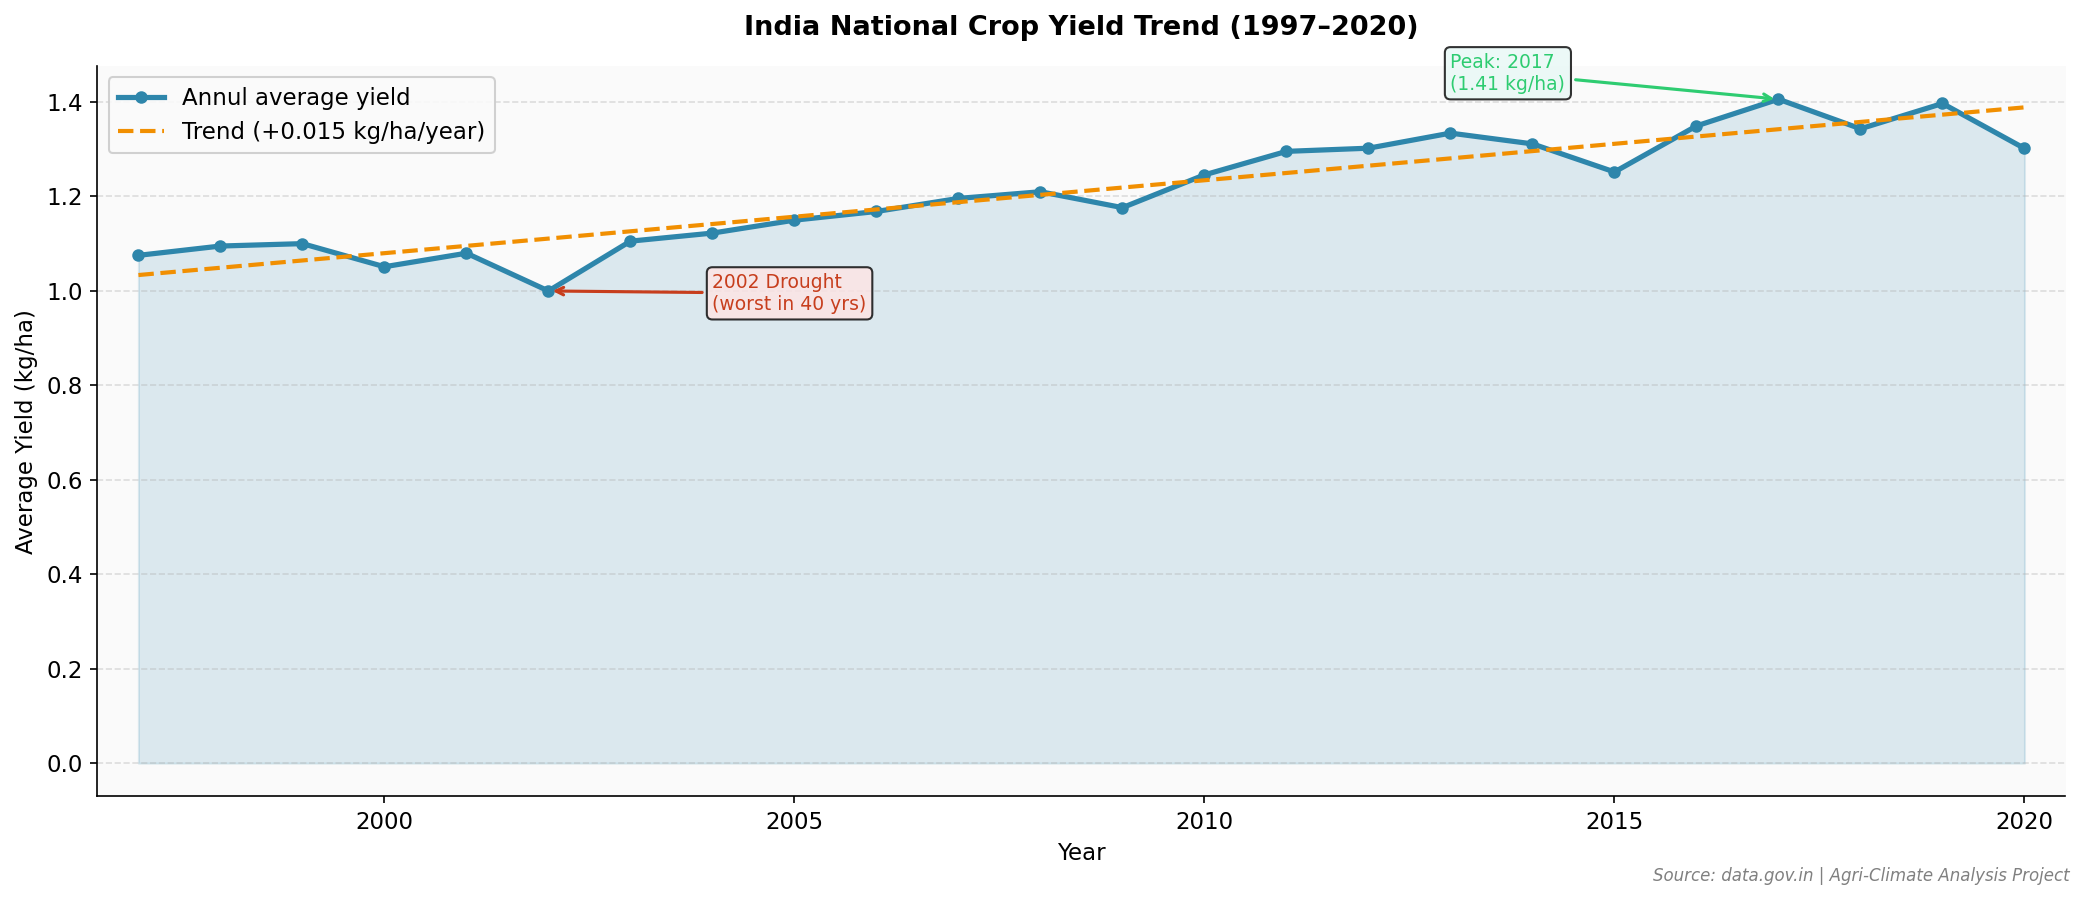

✓ Upgraded yield trend saved


In [ ]:
yearly_yield = crop_df.groupby('Crop_Year')['Yield'].mean()
z = np.polyfit(yearly_yield.index, yearly_yield.values, 1)
p = np.poly1d(z)

fig, ax = plt.subplots(figsize=(14, 6))

# Fill area under line
ax.fill_between(yearly_yield.index, yearly_yield.values,
                alpha=0.15, color=COLORS['primary'])

# Main line
ax.plot(yearly_yield.index, yearly_yield.values,
        color=COLORS['primary'], linewidth=2.5,
        marker='o', markersize=5, label='Annul average yield')

# Trend line
ax.plot(yearly_yield.index, p(yearly_yield.index),
        '--', color=COLORS['warning'], linewidth=2,
        label=f'Trend (+{z[0]:.3f} kg/ha/year)')

# Annotate the 2002 drought
ax.annotate('2002 Drought\n(worst in 40 yrs)',
            xy=(2002, yearly_yield[2002]),
            xytext=(2004, yearly_yield[2002] - 0.04),
            fontsize=9, color=COLORS['danger'],
            arrowprops=dict(arrowstyle='->', color=COLORS['danger'], lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFE5E5', alpha=0.8))

# Annotate peak year
peak_year = yearly_yield.idxmax()
ax.annotate(f'Peak: {peak_year}\n({yearly_yield[peak_year]:.2f} kg/ha)',
            xy=(peak_year, yearly_yield[peak_year]),
            xytext=(peak_year - 4, yearly_yield[peak_year] + 0.02),
            fontsize=9, color=COLORS['success'],
            arrowprops=dict(arrowstyle='->', color=COLORS['success'], lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F8F5', alpha=0.8))

ax.set_title('India National Crop Yield Trend (1997–2020)', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Average Yield (kg/ha)')
ax.legend(loc='upper left', framealpha=0.9)

# Add subtle grid
ax.grid(axis='y', alpha=0.4, linestyle='--')
ax.set_xlim(yearly_yield.index.min() - 0.5, yearly_yield.index.max() + 0.5)

# Footer note
fig.text(0.99, 0.01,
         'Source: data.gov.in | Agri-Climate Analysis Project',
         ha='right', fontsize=8, color='grey', style='italic')

plt.tight_layout()
plt.savefig('plot2_yield_trend_v2.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Upgraded yield trend saved")

***# Publication quality: Upgraded Rice vs Wheat***

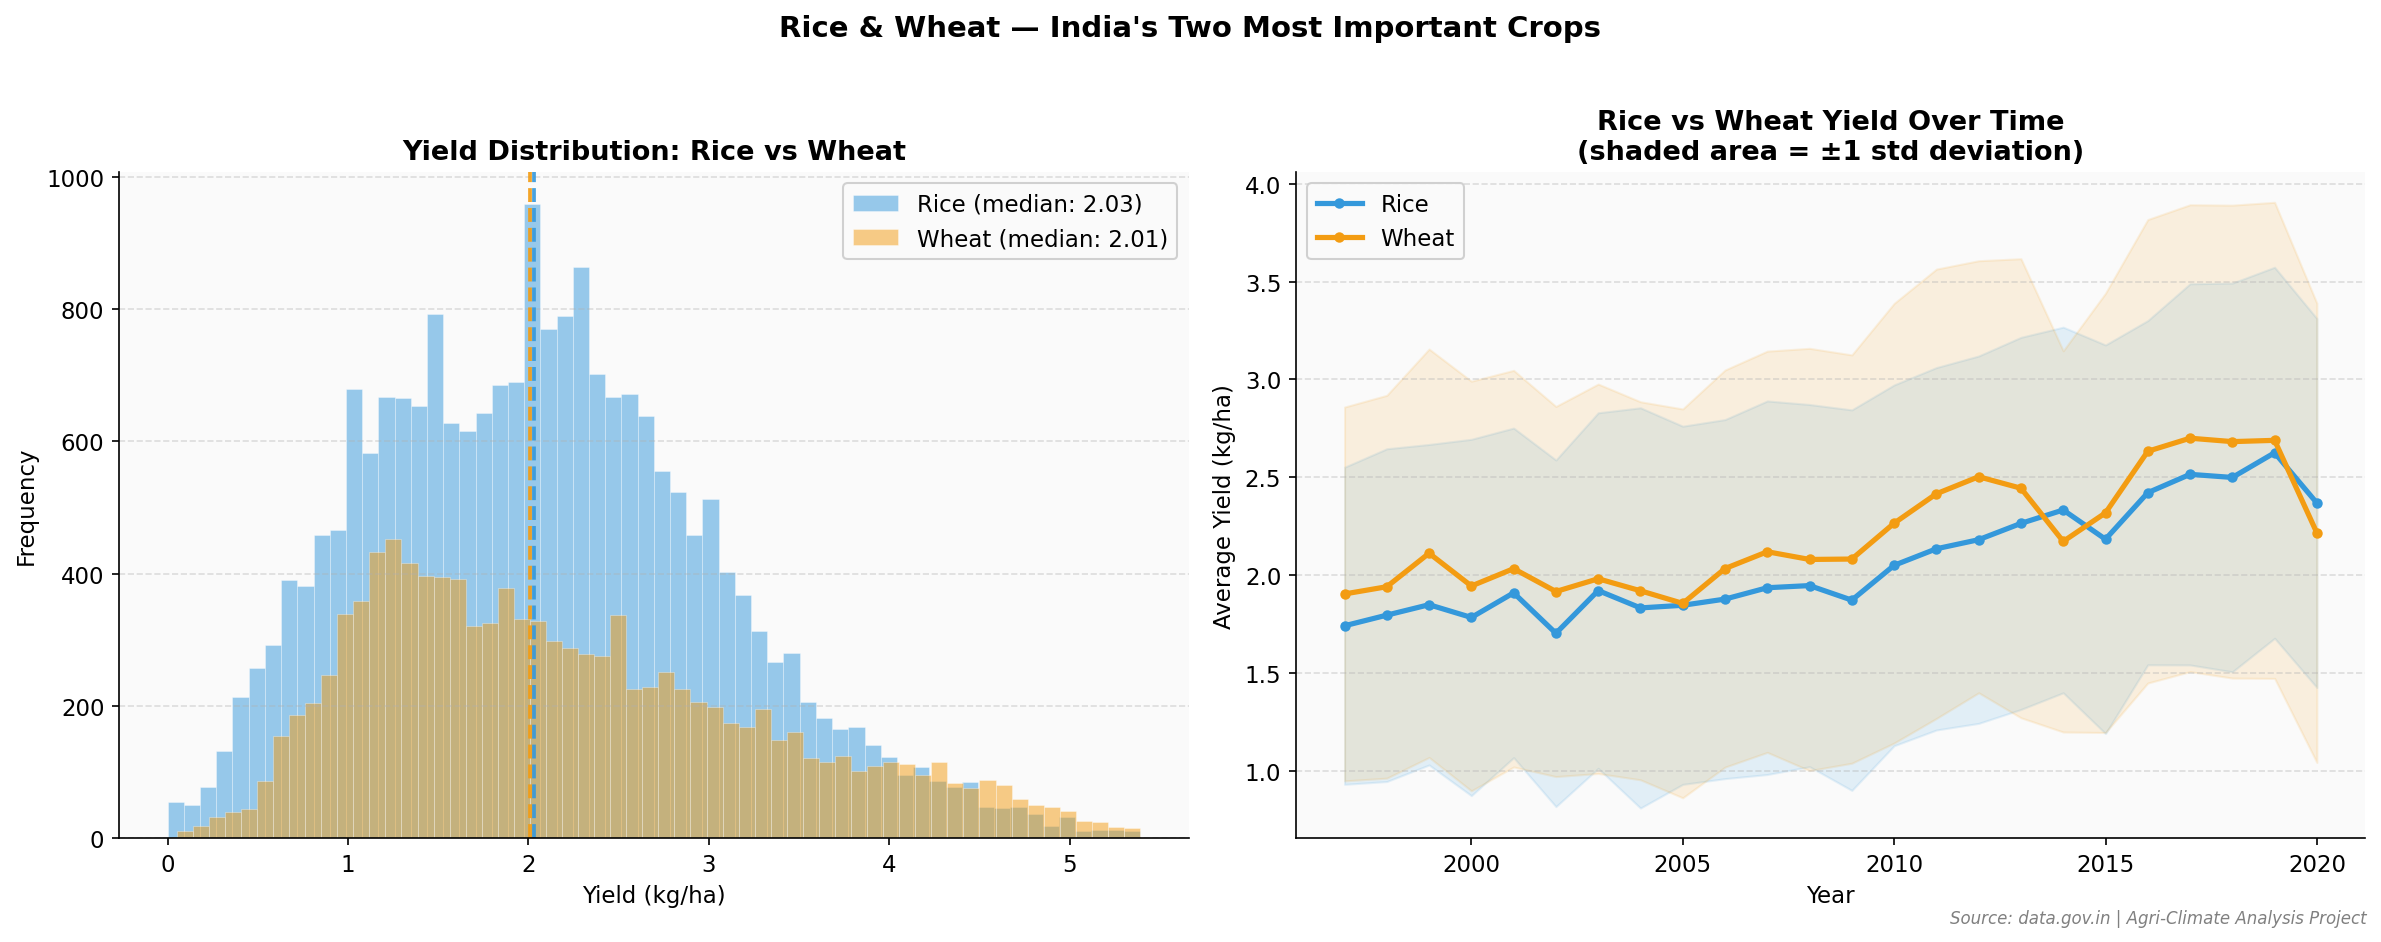

✓ Upgraded rice/wheat chart saved


In [ ]:
focus = crop_df[crop_df['Crop'].isin(['Rice', 'Wheat'])]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── LEFT: Improved histogram with KDE ──
ax = axes[0]
for crop, color, label in [
    ('Rice',  COLORS['rice'],  'Rice'),
    ('Wheat', COLORS['wheat'], 'Wheat')
]:
    data = focus[focus['Crop'] == crop]['Yield']
    ax.hist(data, bins=60, alpha=0.5, color=color,
            label=f'{label} (median: {data.median():.2f})',
            edgecolor='white', linewidth=0.3)
    ax.axvline(data.median(), color=color,
               linestyle='--', linewidth=1.8, alpha=0.9)

ax.set_title('Yield Distribution: Rice vs Wheat')
ax.set_xlabel('Yield (kg/ha)')
ax.set_ylabel('Frequency')
ax.legend(framealpha=0.9)
ax.grid(axis='y', alpha=0.4, linestyle='--')

# ── RIGHT: Improved time series with confidence band ──
ax = axes[1]
for crop, color in [('Rice', COLORS['rice']), ('Wheat', COLORS['wheat'])]:
    yearly = focus[focus['Crop'] == crop].groupby('Crop_Year')['Yield']
    mean   = yearly.mean()
    std    = yearly.std()

    ax.plot(mean.index, mean.values,
            color=color, linewidth=2.5,
            marker='o', markersize=4, label=crop)
    ax.fill_between(mean.index,
                    mean - std, mean + std,
                    alpha=0.12, color=color)  # confidence band

ax.set_title('Rice vs Wheat Yield Over Time\n(shaded area = ±1 std deviation)')
ax.set_xlabel('Year')
ax.set_ylabel('Average Yield (kg/ha)')
ax.legend(framealpha=0.9)
ax.grid(axis='y', alpha=0.4, linestyle='--')

fig.text(0.99, 0.01,
         'Source: data.gov.in | Agri-Climate Analysis Project',
         ha='right', fontsize=8, color='grey', style='italic')

plt.suptitle('Rice & Wheat — India\'s Two Most Important Crops',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot7_rice_wheat_v2.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Upgraded rice/wheat chart saved")

***# The summary panel (4 charts in 1 image)***

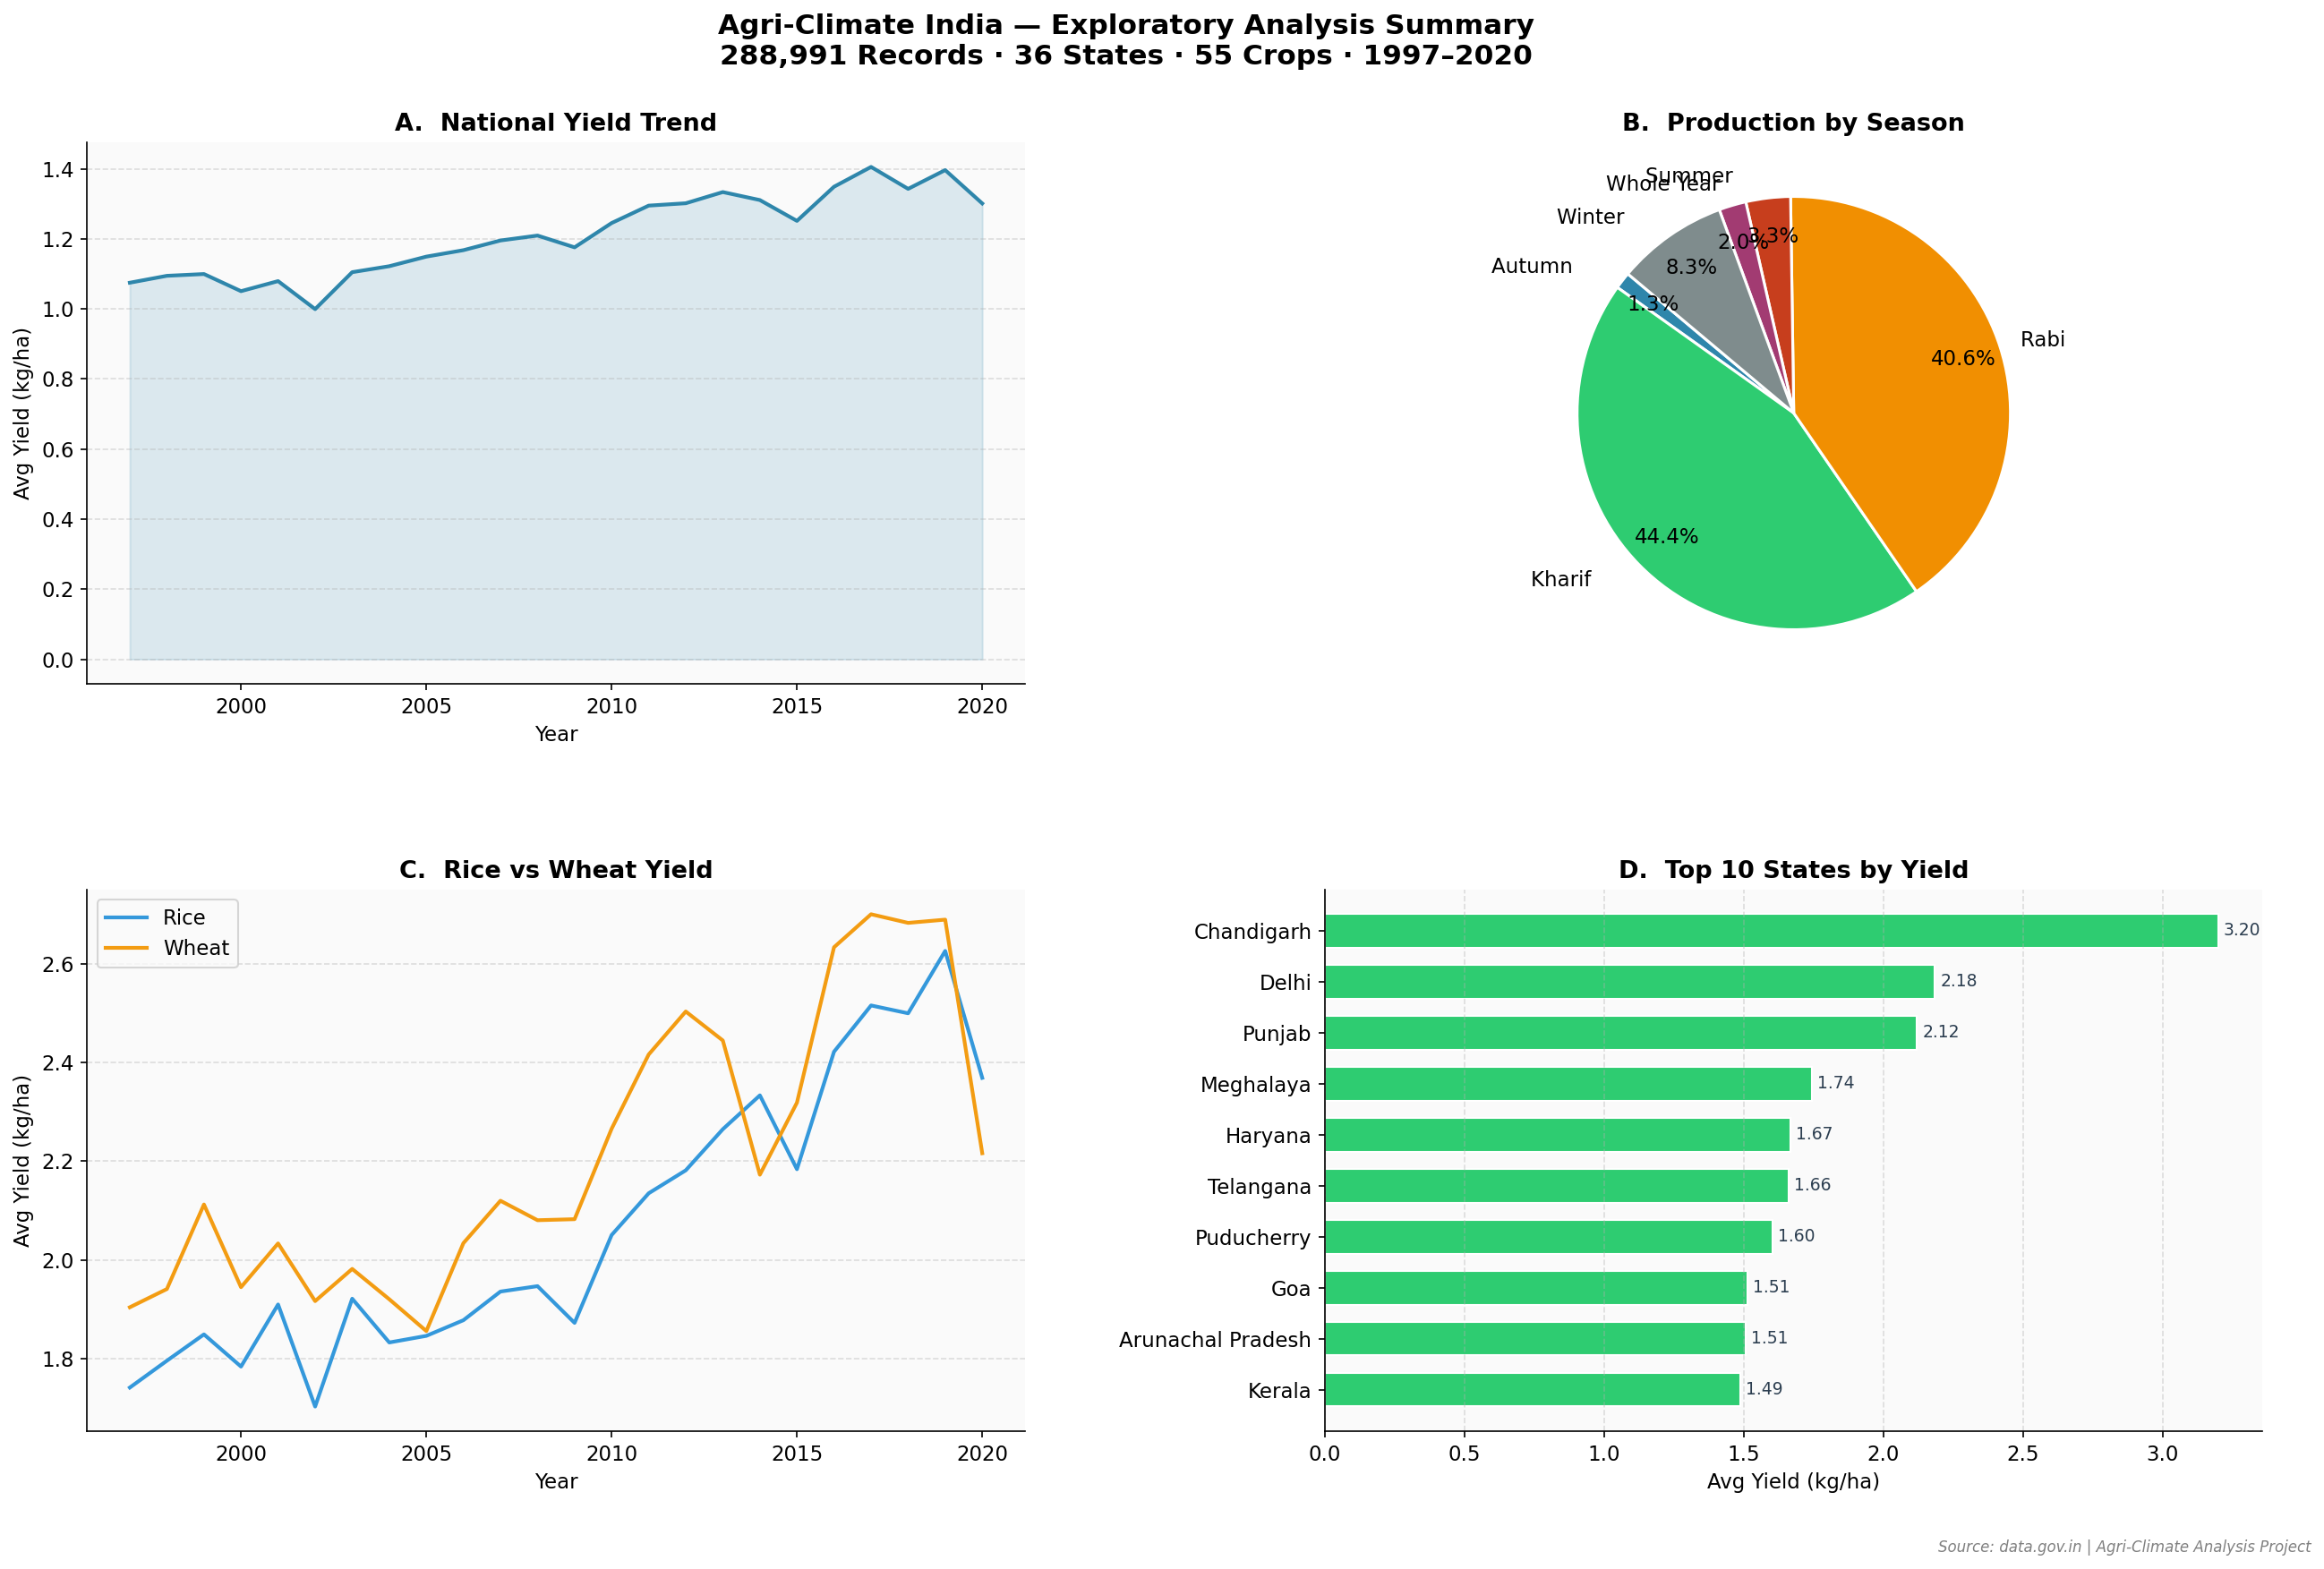

✓ Summary panel saved — this is your GitHub README hero image!


In [ ]:
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('white')

# ── Panel layout ──
gs = fig.add_gridspec(2, 2, hspace=0.38, wspace=0.32,
                      left=0.07, right=0.97, top=0.88, bottom=0.08)

ax1 = fig.add_subplot(gs[0, 0])   # yield trend
ax2 = fig.add_subplot(gs[0, 1])   # season pie
ax3 = fig.add_subplot(gs[1, 0])   # rice vs wheat
ax4 = fig.add_subplot(gs[1, 1])   # top 10 states

# ── Panel 1: Yield trend ──
yearly_yield = crop_df.groupby('Crop_Year')['Yield'].mean()
ax1.fill_between(yearly_yield.index, yearly_yield.values,
                 alpha=0.15, color=COLORS['primary'])
ax1.plot(yearly_yield.index, yearly_yield.values,
         color=COLORS['primary'], linewidth=2)
ax1.set_title('A.  National Yield Trend')
ax1.set_xlabel('Year'); ax1.set_ylabel('Avg Yield (kg/ha)')
ax1.grid(axis='y', alpha=0.4, linestyle='--')

# ── Panel 2: Season pie ──
season_prod = crop_df.groupby('Season')['Production'].sum()
colors_pie  = [COLORS['primary'], COLORS['success'], COLORS['warning'],
               COLORS['danger'], COLORS['secondary'], '#7f8c8d']
ax2.pie(season_prod.values, labels=season_prod.index,
        autopct='%1.1f%%', colors=colors_pie[:len(season_prod)],
        startangle=140, pctdistance=0.82,
        wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax2.set_title('B.  Production by Season')

# ── Panel 3: Rice vs Wheat trend ──
for crop, color in [('Rice', COLORS['rice']), ('Wheat', COLORS['wheat'])]:
    d = focus[focus['Crop'] == crop].groupby('Crop_Year')['Yield'].mean()
    ax3.plot(d.index, d.values, color=color, linewidth=2, label=crop)
ax3.set_title('C.  Rice vs Wheat Yield')
ax3.set_xlabel('Year'); ax3.set_ylabel('Avg Yield (kg/ha)')
ax3.legend(); ax3.grid(axis='y', alpha=0.4, linestyle='--')

# ── Panel 4: Top 10 states ──
state_yield = crop_df.groupby('State')['Yield'].mean().sort_values(ascending=False)
top10 = state_yield.head(10)
bars  = ax4.barh(top10.index[::-1], top10.values[::-1],
                 color=COLORS['success'], edgecolor='white', height=0.65)
# Add value labels on bars
for bar, val in zip(bars, top10.values[::-1]):
    ax4.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9, color=COLORS['dark'])
ax4.set_title('D.  Top 10 States by Yield')
ax4.set_xlabel('Avg Yield (kg/ha)')
ax4.grid(axis='x', alpha=0.4, linestyle='--')

# ── Main title and source ──
fig.suptitle('Agri-Climate India — Exploratory Analysis Summary\n288,991 Records · 36 States · 55 Crops · 1997–2020',
             fontsize=15, fontweight='bold', y=0.96)
fig.text(0.99, 0.005,
         'Source: data.gov.in | Agri-Climate Analysis Project',
         ha='right', fontsize=8, color='grey', style='italic')

plt.savefig('summary_panel.png', bbox_inches='tight', dpi=150)
plt.show()
print("✓ Summary panel saved — this is your GitHub README hero image!")

***# Save Everithing***

In [ ]:
from google.colab import files

# List all files generated this week
import os
week5_files = [f for f in os.listdir() if f.endswith(('.png', '.html'))]
print("Files generated this week:")
for f in sorted(week5_files):
    size_kb = os.path.getsize(f) // 1024
    print(f"  {f} ({size_kb} KB)")

Files generated this week:
  india_crop_yield_map.html (41552 KB)
  plot2_yield_trend_v2.png (109 KB)
  plot7_rice_wheat_v2.png (181 KB)
  summary_panel.png (287 KB)
